# Notebook 02 — The Perceptron
**DSC 240 · Machine Learning · UCSD**

Rosenblatt (1957) described it as *"the first device to think as the human brain."*  
Novikoff (1962) proved it converges in finite steps — if the data is linearly separable.

In this notebook:
1. Implement the Perceptron update rule from scratch
2. Visualize how the decision boundary evolves
3. Verify Novikoff's convergence bound empirically
4. Explore what happens when data is *not* linearly separable

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import FancyArrowPatch

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'pos': '#E63946', 'neg': '#457B9D', 'boundary': '#2D6A4F', 'update': '#F4A261'}

## 1. The Algorithm

Given labeled data $(x_1, y_1), \ldots, (x_n, y_n)$ with $y_i \in \{+1, -1\}$:

**Initialize:** $w = 0$

**Repeat until convergence:**
- For each $(x_i, y_i)$:
  - If $\text{sign}(\langle w, x_i \rangle) \neq y_i$: update $w \leftarrow w + y_i \cdot x_i$

The decision boundary is the hyperplane $\{x : \langle w, x \rangle = 0\}$.

In [4]:
class Perceptron:
    """Perceptron classifier with full training history."""
    
    def __init__(self):
        self.w = None
        self.history = []  # list of (w_snapshot, update_point, update_label)
        self.n_updates = 0
    
    def fit(self, X, y, max_epochs=100):
        """Train perceptron. X: (n, d), y: (n,) with values in {+1, -1}."""
        n, d = X.shape
        self.w = np.zeros(d)
        self.history = [(self.w.copy(), None, None)]
        
        for epoch in range(max_epochs):
            errors = 0
            for i in range(n):
                if np.sign(self.w @ X[i]) != y[i]:
                    self.w = self.w + y[i] * X[i]
                    self.history.append((self.w.copy(), X[i], y[i]))
                    self.n_updates += 1
                    errors += 1
            if errors == 0:
                print(f'Converged after {epoch+1} epoch(s), {self.n_updates} total updates.')
                return self
        
        print(f'Did not converge in {max_epochs} epochs. Data may not be separable.')
        return self
    
    def predict(self, X):
        return np.sign(X @ self.w)

## 2. Generate Linearly Separable Data

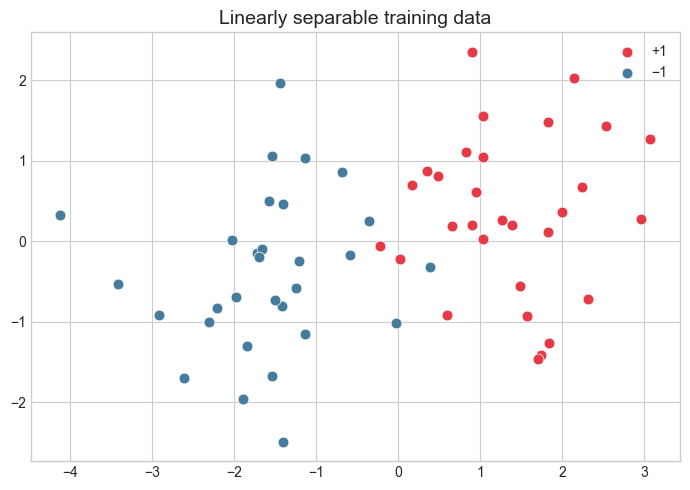

In [5]:
def make_separable(n=60, margin=0.5, seed=42):
    """Generate 2D data linearly separable with a known margin."""
    rng = np.random.RandomState(seed)
    # True boundary: x[0] + x[1] = 0 (the diagonal)
    X_pos = rng.randn(n//2, 2) + np.array([1.5, 0.5])
    X_neg = rng.randn(n//2, 2) + np.array([-1.5, -0.5])
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(n//2), -np.ones(n//2)])
    return X, y

X, y = make_separable(n=60)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[y==1, 0], X[y==1, 1], c=COLORS['pos'], label='+1', s=60, edgecolors='white', linewidth=0.5)
ax.scatter(X[y==-1, 0], X[y==-1, 1], c=COLORS['neg'], label='−1', s=60, edgecolors='white', linewidth=0.5)
ax.set_title('Linearly separable training data', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../assets/figures/perceptron_data.png', dpi=120)
plt.show()

## 3. Train and Visualize Boundary Evolution

Did not converge in 100 epochs. Data may not be separable.


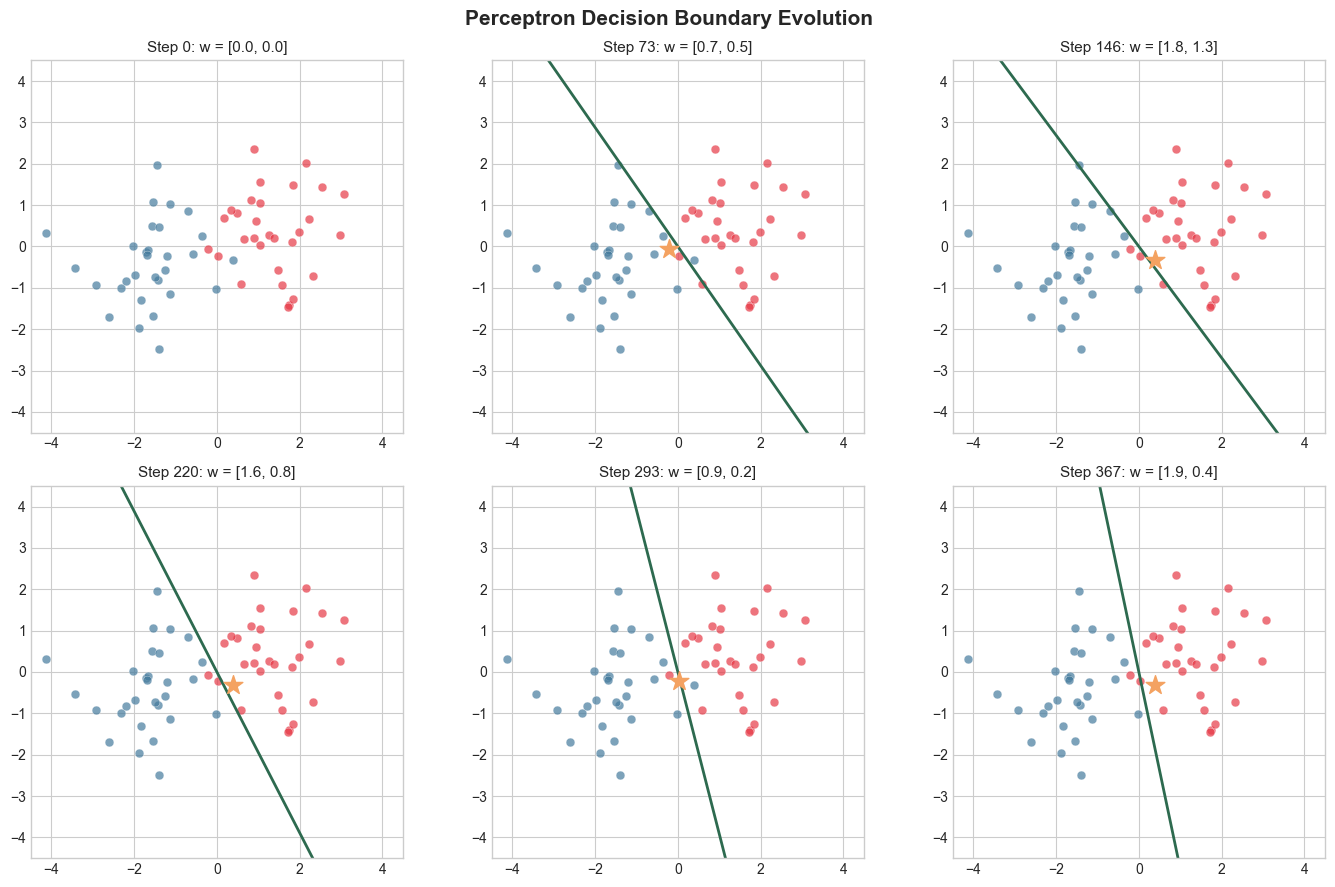

In [6]:
p = Perceptron()
p.fit(X, y)

def plot_boundary(ax, w, x_range=(-4, 4), **kwargs):
    """Plot the hyperplane <w, x> = 0 in 2D."""
    if abs(w[1]) < 1e-10:
        return
    xs = np.linspace(*x_range, 200)
    ys = -w[0] / w[1] * xs
    ax.plot(xs, ys, **kwargs)

# Show snapshots at key update steps
checkpoints = np.linspace(0, len(p.history)-1, 6, dtype=int)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, step in zip(axes.flat, checkpoints):
    w_snap, upd_pt, upd_y = p.history[step]
    ax.scatter(X[y==1, 0], X[y==1, 1], c=COLORS['pos'], s=40, alpha=0.7, edgecolors='white', lw=0.3)
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c=COLORS['neg'], s=40, alpha=0.7, edgecolors='white', lw=0.3)
    if np.any(w_snap != 0):
        plot_boundary(ax, w_snap, color=COLORS['boundary'], lw=2, label='boundary')
    if upd_pt is not None:
        c = COLORS['pos'] if upd_y == 1 else COLORS['neg']
        ax.scatter(*upd_pt, s=200, c=COLORS['update'], marker='*', zorder=5, label='updated on')
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_title(f'Step {step}: w = [{w_snap[0]:.1f}, {w_snap[1]:.1f}]', fontsize=11)
    ax.set_aspect('equal')

fig.suptitle('Perceptron Decision Boundary Evolution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/figures/perceptron_evolution.png', dpi=120)
plt.show()

## 4. Novikoff's Convergence Bound

**Theorem (Novikoff, 1962):** If data is separable with margin $m$ (i.e., $\exists w^*$ with $\|w^*\|=1$ such that $y_i \langle w^*, x_i \rangle \geq m$ for all $i$), and $\|x_i\| \leq M$, then the Perceptron makes at most

$$T \leq \frac{M^2 \|w^*\|^2}{m^2}$$

mistakes.

**Proof sketch** (two ways to bound $\|w_T\|$):
- Lower bound via dot product with $w^*$: each update increases $\langle w_T, w^* \rangle$ by at least $m$
- Upper bound via norm growth: each update adds at most $M^2$ to $\|w_T\|^2$

Combining: $T \cdot m^2 \leq \|w_T\|^2 \leq T \cdot M^2$... wait, more carefully: $T \leq (M \|w^*\| / m)^2$.

Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.
Converged after 2 epoch(s), 1 total updates.


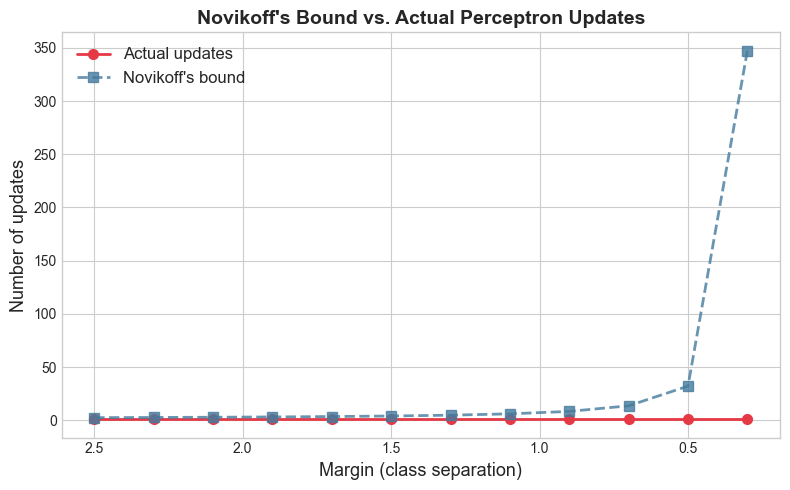

Bound is tight (actual ≤ bound): True


In [7]:
def compute_margin(X, y, w):
    """Functional margin of w on dataset (X, y)."""
    w_norm = np.linalg.norm(w)
    if w_norm < 1e-10:
        return 0.0
    return np.min(y * (X @ w)) / w_norm

# Vary the margin by shifting class means and count actual updates
margins = np.linspace(0.3, 2.5, 12)
actual_updates = []
novikoff_bounds = []

for m_target in margins:
    X_m = make_separable(n=80, seed=7)[0]
    # Scale so classes are separated by m_target
    X_pos = X_m[:40] * 0.3 + np.array([m_target, 0])
    X_neg = X_m[40:] * 0.3 + np.array([-m_target, 0])
    Xm = np.vstack([X_pos, X_neg])
    ym = np.hstack([np.ones(40), -np.ones(40)])
    
    perc = Perceptron()
    perc.fit(Xm, ym, max_epochs=500)
    actual_updates.append(perc.n_updates)
    
    # Novikoff bound: T ≤ (M * ‖w*‖ / m)²  
    # With normalized w* and M = max norm of data
    M = np.max(np.linalg.norm(Xm, axis=1))
    w_star = np.array([1.0, 0.0])  # true separating direction
    m_actual = compute_margin(Xm, ym, w_star)
    bound = (M / max(m_actual, 1e-6)) ** 2
    novikoff_bounds.append(bound)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(margins, actual_updates, 'o-', color=COLORS['pos'], lw=2, label='Actual updates', markersize=7)
ax.plot(margins, novikoff_bounds, 's--', color=COLORS['neg'], lw=2, label="Novikoff's bound", markersize=7, alpha=0.8)
ax.set_xlabel('Margin (class separation)', fontsize=13)
ax.set_ylabel('Number of updates', fontsize=13)
ax.set_title("Novikoff's Bound vs. Actual Perceptron Updates", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.invert_xaxis()  # Small margin → many updates (left side)
plt.tight_layout()
plt.savefig('../assets/figures/novikoff_bound.png', dpi=120)
plt.show()
print('Bound is tight (actual ≤ bound):', all(a <= b + 1 for a, b in zip(actual_updates, novikoff_bounds)))

## 5. Non-Separable Data

When classes overlap, the Perceptron never converges — it cycles forever. This motivated SVMs (soft margin) and the need for a different algorithmic approach.

Did not converge in 50 epochs. Data may not be separable.


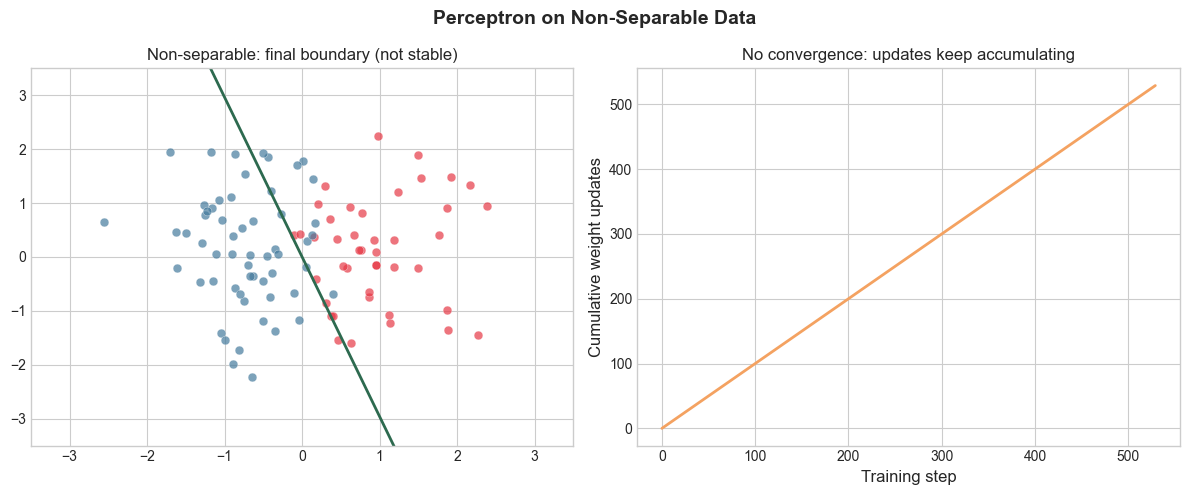

In [8]:
# Overlapping classes
rng = np.random.RandomState(0)
X_ns = rng.randn(100, 2)
y_ns = np.sign(X_ns[:, 0] + 0.3 * rng.randn(100))  # noisy labels
y_ns[y_ns == 0] = 1

p_ns = Perceptron()
p_ns.fit(X_ns, y_ns, max_epochs=50)

update_counts = list(range(len(p_ns.history)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Final boundary
ax1.scatter(X_ns[y_ns==1, 0], X_ns[y_ns==1, 1], c=COLORS['pos'], s=40, alpha=0.7, edgecolors='white', lw=0.3)
ax1.scatter(X_ns[y_ns==-1, 0], X_ns[y_ns==-1, 1], c=COLORS['neg'], s=40, alpha=0.7, edgecolors='white', lw=0.3)
plot_boundary(ax1, p_ns.w, color=COLORS['boundary'], lw=2)
ax1.set_title('Non-separable: final boundary (not stable)', fontsize=12)
ax1.set_xlim(-3.5, 3.5); ax1.set_ylim(-3.5, 3.5)

# Cumulative updates per epoch
ax2.plot(update_counts, color=COLORS['update'], lw=2)
ax2.set_xlabel('Training step', fontsize=12)
ax2.set_ylabel('Cumulative weight updates', fontsize=12)
ax2.set_title('No convergence: updates keep accumulating', fontsize=12)

plt.suptitle('Perceptron on Non-Separable Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/figures/perceptron_nonseparable.png', dpi=120)
plt.show()

## Summary

| Property | Value |
|----------|-------|
| Time per update | O(d) |
| Convergence condition | Linear separability |
| Convergence bound | T ≤ (M·‖w*‖/m)² |
| Key parameter | Margin m |
| Limitation | No convergence for overlapping classes |

**Next up:** SVMs fix the non-separable case with soft margins (`03_svm.ipynb`).